<div style="text-align: center;">
    <h1>Red Neuronal Artificial — Multilayer Perceptron</h1>
    <h3>Clasificación de Enfermedad Cardiovascular</h3>
</div>

## 1. Importar librerías

Este notebook usa una red neuronal tipo **Multilayer Perceptron (MLP)** con `MLPClassifier`.

La métrica oficial de búsqueda y selección será **ROC-AUC**, para mantener consistencia con el flujo de Random Forest.  
F2, recall y falsos negativos se mantienen como métricas secundarias relevantes para el contexto cardiovascular.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import loguniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,fbeta_score,roc_auc_score,confusion_matrix,classification_report,make_scorer,RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Cargar datos

Se carga la base de datos limpia desde el repositorio del proyecto.

In [2]:
try:
    data = pd.read_csv(
        "https://raw.githubusercontent.com/SantCorrea802/Cardiovascular_Disease_Proyecto_Modelos_II/main/dataset/data_cleaned.csv"
    )
except FileNotFoundError:
    print("No se ha encontrado el archivo de datos. Verifique el directorio.")
    raise

data.head()

,age,gender,height,weight,systolic_blood_pressure,diastolic_blood_pressure,cholesterol,glucose,smoke,alcohol_intake,physical_activity,bmi,cardiovascular_disease
0,50,2,168,62.0,110,80,1,1,0,0,1,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,3,1
2,52,1,165,64.0,130,70,3,1,0,0,0,1,1
3,48,2,169,82.0,150,100,1,1,0,0,1,2,1
4,48,1,156,56.0,100,60,1,1,0,0,0,1,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68589 entries, 0 to 68588
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       68589 non-null  int64  
 1   gender                    68589 non-null  int64  
 2   height                    68589 non-null  int64  
 3   weight                    68589 non-null  float64
 4   systolic_blood_pressure   68589 non-null  int64  
 5   diastolic_blood_pressure  68589 non-null  int64  
 6   cholesterol               68589 non-null  int64  
 7   glucose                   68589 non-null  int64  
 8   smoke                     68589 non-null  int64  
 9   alcohol_intake            68589 non-null  int64  
 10  physical_activity         68589 non-null  int64  
 11  bmi                       68589 non-null  int64  
 12  cardiovascular_disease    68589 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.8 MB


## 3. Separación Train / Validation / Test

Se usa la misma estrategia del proyecto:

- 80% entrenamiento
- 10% validación
- 10% test

El conjunto de test se mantiene reservado hasta el final.

In [4]:
target_column = "cardiovascular_disease"

if target_column not in data.columns:
    raise ValueError(f"No existe la columna objetivo: {target_column}")

features = data.drop(columns=[target_column])
target = data[target_column]

X_train, X_temp, y_train, y_temp = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nDistribución train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución validation:")
print(y_val.value_counts(normalize=True))

print("\nDistribución test:")
print(y_test.value_counts(normalize=True))

X_train: (54871, 12)
X_val:   (6859, 12)
X_test:  (6859, 12)

Distribución train:
cardiovascular_disease
0    0.504966
1    0.495034
Name: proportion, dtype: float64

Distribución validation:
cardiovascular_disease
0    0.504884
1    0.495116
Name: proportion, dtype: float64

Distribución test:
cardiovascular_disease
0    0.50503
1    0.49497
Name: proportion, dtype: float64


## 4. Definición de tipos de variables

Se conserva una separación compatible con el dataset cardiovascular usado en el proyecto.

In [5]:
categorical = [
    "gender",
    "cholesterol",
    "glucose",
    "smoke",
    "alcohol_intake",
    "physical_activity",
    "bmi"
]

nominal = [
    "gender",
    "smoke",
    "alcohol_intake",
    "physical_activity"
]

ordinal = [
    "cholesterol",
    "glucose",
    "bmi"
]

numerical = [
    "age",
    "height",
    "weight",
    "systolic_blood_pressure",
    "diastolic_blood_pressure"
]

expected_columns = set(nominal + ordinal + numerical)
missing_columns = expected_columns - set(X_train.columns)

if missing_columns:
    raise ValueError(f"Faltan columnas esperadas en el dataset: {missing_columns}")

## 5. Preprocesamiento para MLP

Para una red neuronal tipo MLP, el escalado de variables numéricas es obligatorio en la práctica.

Decisión de ingeniería:

- Variables numéricas: `StandardScaler`.
- Variables nominales: `OneHotEncoder`.
- Variables ordinales: `OrdinalEncoder` + `StandardScaler`.
- Salida densa: se fuerza salida densa para evitar problemas de compatibilidad/rendimiento con MLP.

In [6]:
# Categorías esperadas para variables ordinales:
# cholesterol: 1, 2, 3
# glucose: 1, 2, 3
# bmi: 0, 1, 2, 3, 4, 5
ordinal_categories = [
    [1, 2, 3],
    [1, 2, 3],
    [0, 1, 2, 3, 4, 5]
]

ordinal_pipeline = Pipeline(
    steps=[
        ("encoder", OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-2
        )),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal),
        ("ord", ordinal_pipeline, ordinal)
    ],
    remainder="drop",
    sparse_threshold=0
)

## 6. Funciones auxiliares de métricas

Se reportan las mismas métricas relevantes del flujo de SVM:

- accuracy
- precision
- recall
- f1
- f2
- roc_auc
- TN, FP, FN, TP

`zero_division=0` evita warnings cuando algún candidato no predice positivos.

Las matrices de confusión se grafican con **conteo absoluto y porcentaje por clase real**. Es decir, cada fila suma aproximadamente 100%.


In [7]:
def get_decision_scores(model, X):
    """
    Retorna scores continuos para ROC-AUC y ajuste de threshold.

    Para MLPClassifier se usa predict_proba(X)[:, 1].
    Se deja fallback a decision_function por compatibilidad con otros modelos.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    raise AttributeError(
        "El modelo no expone predict_proba ni decision_function; no se puede calcular ROC-AUC."
    )


def get_scores_from_predictions(y_true, y_pred, y_score, model_name, split_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }, cm


def get_scores(model, X, y, model_name, split_name, threshold=0.5):
    y_score = get_decision_scores(model, X)
    y_pred = (y_score >= threshold).astype(int)

    return get_scores_from_predictions(
        y_true=y,
        y_pred=y_pred,
        y_score=y_score,
        model_name=model_name,
        split_name=split_name
    )


def plot_confusion_matrix_percent(cm, title, class_labels=("Clase 0", "Clase 1")):
    """
    Grafica matriz de confusión con conteos y porcentajes por clase real.

    Porcentaje por fila:
    - Fila Real 0: TN y FP suman 100%.
    - Fila Real 1: FN y TP suman 100%.
    """
    cm = np.asarray(cm)

    row_totals = cm.sum(axis=1, keepdims=True)
    cm_percent = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0
    ) * 100

    annotations = np.empty_like(cm, dtype=object)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotations[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

    plt.figure(figsize=(5.8, 4.6))

    sns.heatmap(
        cm_percent,
        annot=annotations,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=100,
        xticklabels=[f"Pred {label}" for label in class_labels],
        yticklabels=[f"Real {label}" for label in class_labels],
        cbar_kws={"label": "% por clase real"}
    )

    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 7. Scorers para búsqueda de hiperparámetros

La búsqueda calcula varias métricas, pero la selección oficial del mejor modelo usa:

```python
refit="roc_auc"
```

Esto replica el criterio oficial usado para Random Forest.

In [8]:
precision_scorer = make_scorer(
    precision_score,
    zero_division=0
)

recall_scorer = make_scorer(
    recall_score,
    zero_division=0
)

f1_scorer = make_scorer(
    f1_score,
    zero_division=0
)

f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

scoring = {
    "accuracy": "accuracy",
    "precision": precision_scorer,
    "recall": recall_scorer,
    "f1": f1_scorer,
    "roc_auc": "roc_auc",
    "f2": f2_scorer
}

official_refit_metric = "roc_auc"

## 8. Modelos base

Se entrenan tres modelos base:

1. Dummy classifier.
2. MLP base.
3. MLP alternativo más regularizado.

El objetivo no es todavía elegir el mejor final, sino tener una comparación inicial antes del tuning.

In [9]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(
        strategy="most_frequent",
        random_state=42
    ))
])

mlp_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        batch_size=64,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=25,
        tol=1e-4,
        random_state=42
    ))
])

mlp_regularized = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="tanh",
        solver="adam",
        alpha=1e-3,
        learning_rate_init=1e-3,
        batch_size=64,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=25,
        tol=1e-4,
        random_state=42
    ))
])

In [10]:
base_models = {
    "Dummy": dummy_model,
    "MLP base relu (32,16)": mlp_base,
    "MLP tanh regularized (64,32)": mlp_regularized
}

trained_base_models = {}

for model_name, model in base_models.items():
    print(f"Entrenando: {model_name}")

    # Durante entrenamiento de redes neuronales puede aparecer ConvergenceWarning
    # si algún entrenamiento alcanza max_iter. Con early_stopping y max_iter=500
    # el caso debería reducirse; si aparece, no invalida automáticamente el modelo,
    # pero debe revisarse la curva de pérdida.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        trained_base_models[model_name] = model.fit(X_train, y_train)

print("Entrenamiento base finalizado.")

Entrenando: Dummy
Entrenando: MLP base relu (32,16)
Entrenando: MLP tanh regularized (64,32)
Entrenamiento base finalizado.


## 9. Evaluación de modelos base en train y validation

In [11]:
base_results = []
base_confusion_matrices = {}

for model_name, model in trained_base_models.items():
    train_scores, train_cm = get_scores(
        model=model,
        X=X_train,
        y=y_train,
        model_name=model_name,
        split_name="train",
        threshold=0.5
    )

    val_scores, val_cm = get_scores(
        model=model,
        X=X_val,
        y=y_val,
        model_name=model_name,
        split_name="validation",
        threshold=0.5
    )

    base_results.extend([train_scores, val_scores])
    base_confusion_matrices[(model_name, "train")] = train_cm
    base_confusion_matrices[(model_name, "validation")] = val_cm

base_results_df = pd.DataFrame(base_results)

base_results_df.sort_values(
    by=["split", "roc_auc", "f2"],
    ascending=[True, False, False]
)

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
2,"MLP base relu (32,16)",train,0.736692,0.756196,0.690829,0.722036,0.702983,0.804951,21658,6050,8398,18765
4,"MLP tanh regularized (64,32)",train,0.736236,0.750890,0.699113,0.724077,0.708889,0.802080,21408,6300,8173,18990
0,Dummy,train,0.504966,0.000000,0.000000,0.000000,0.000000,0.500000,27708,0,27163,0
5,"MLP tanh regularized (64,32)",validation,0.736405,0.750158,0.701119,0.724810,0.710407,0.806683,2670,793,1015,2381
3,"MLP base relu (32,16)",validation,0.739321,0.760026,0.691991,0.724414,0.704605,0.806200,2721,742,1046,2350
1,Dummy,validation,0.504884,0.000000,0.000000,0.000000,0.000000,0.500000,3463,0,3396,0


In [12]:
base_validation_results = base_results_df[
    base_results_df["split"] == "validation"
].sort_values(
    by=["roc_auc", "f2", "FN", "recall"],
    ascending=[False, False, True, False]
)

base_validation_results

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
5,"MLP tanh regularized (64,32)",validation,0.736405,0.750158,0.701119,0.724810,0.710407,0.806683,2670,793,1015,2381
3,"MLP base relu (32,16)",validation,0.739321,0.760026,0.691991,0.724414,0.704605,0.806200,2721,742,1046,2350
1,Dummy,validation,0.504884,0.000000,0.000000,0.000000,0.000000,0.500000,3463,0,3396,0


## 10. Búsqueda de hiperparámetros del MLP

La búsqueda usa `RandomizedSearchCV`.

Ajustes para hacerla más robusta que una prueba mínima:

- `n_iter=32`: más combinaciones que una búsqueda muy ligera.
- `loguniform` para `alpha` y `learning_rate_init`: explora órdenes de magnitud, no solo valores fijos.
- arquitecturas pequeñas, medianas y algo más anchas.
- `solver="adam"`: más estable para este flujo que mezclar `sgd` en una primera búsqueda.
- `early_stopping=True`: detiene entrenamientos sin mejora.
- `max_iter=700`: reduce falsos `ConvergenceWarning`.
- `n_jobs=1`: evita problemas de memoria/procesos en Colab/Kaggle.
- `error_score=np.nan`: si una combinación falla, no detiene todo el experimento.


In [13]:
mlp_search_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        solver="adam",
        max_iter=700,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        tol=1e-4,
        random_state=42
    ))
])

param_distributions = {
    "model__hidden_layer_sizes": [
        (16,),
        (32,),
        (64,),
        (128,),
        (32, 16),
        (64, 32),
        (128, 64),
        (64, 32, 16),
        (128, 64, 32),
        (256, 128)
    ],
    "model__activation": ["relu", "tanh"],
    "model__alpha": loguniform(1e-5, 1e-1),
    "model__learning_rate_init": loguniform(1e-4, 3e-3),
    "model__batch_size": [32, 64, 128, 256]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mlp_random_search = RandomizedSearchCV(
    estimator=mlp_search_pipeline,
    param_distributions=param_distributions,
    n_iter=32,
    scoring=scoring,
    refit=official_refit_metric,
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=1,
    return_train_score=True,
    error_score=np.nan
)


In [14]:
with warnings.catch_warnings():
    # Algunas combinaciones pueden no converger antes de early stopping.
    # Eso no invalida la búsqueda; se selecciona por ROC-AUC promedio en CV.
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    mlp_random_search.fit(X_train, y_train)

print("Mejor ROC-AUC promedio en CV:", mlp_random_search.best_score_)
print("Mejores hiperparámetros:")
print(mlp_random_search.best_params_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END model__activation=relu, model__alpha=0.015352246941973482, model__batch_size=128, model__hidden_layer_sizes=(64, 32, 16), model__learning_rate_init=0.0007661100707771367; total time=  16.4s
[CV] END model__activation=relu, model__alpha=0.015352246941973482, model__batch_size=128, model__hidden_layer_sizes=(64, 32, 16), model__learning_rate_init=0.0007661100707771367; total time=  10.0s
[CV] END model__activation=relu, model__alpha=0.015352246941973482, model__batch_size=128, model__hidden_layer_sizes=(64, 32, 16), model__learning_rate_init=0.0007661100707771367; total time=  10.4s
[CV] END model__activation=relu, model__alpha=0.015352246941973482, model__batch_size=128, model__hidden_layer_sizes=(64, 32, 16), model__learning_rate_init=0.0007661100707771367; total time=  12.3s
[CV] END model__activation=relu, model__alpha=0.015352246941973482, model__batch_size=128, model__hidden_layer_sizes=(64, 32, 16), model__lear

## 11. Resultados de la búsqueda

Aunque el modelo se selecciona oficialmente por ROC-AUC, se inspeccionan F2, recall y falsos negativos como métricas secundarias.

In [15]:
search_results = pd.DataFrame(mlp_random_search.cv_results_)

search_cols = [
    "mean_train_roc_auc",
    "mean_test_roc_auc",
    "std_test_roc_auc",
    "mean_test_f2",
    "mean_test_recall",
    "mean_test_precision",
    "mean_test_f1",
    "param_model__hidden_layer_sizes",
    "param_model__activation",
    "param_model__alpha",
    "param_model__learning_rate_init",
    "param_model__batch_size"
]

available_search_cols = [col for col in search_cols if col in search_results.columns]

search_results[available_search_cols].sort_values(
    by="mean_test_roc_auc",
    ascending=False
).head(10)

,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_test_f2,mean_test_recall,mean_test_precision,mean_test_f1,param_model__hidden_layer_sizes,param_model__activation,param_model__alpha,param_model__learning_rate_init,param_model__batch_size
14,0.801815,0.798712,0.003165,0.706029,0.696278,0.748014,0.721193,"(32, 16)",tanh,0.000015,0.000375,256
4,0.802264,0.798574,0.003551,0.695576,0.682325,0.754384,0.716484,"(128, 64, 32)",tanh,0.001256,0.000269,256
2,0.801895,0.798495,0.003088,0.705567,0.696758,0.745009,0.719518,"(32, 16)",tanh,0.006797,0.002708,64
6,0.801327,0.798430,0.003453,0.706052,0.696867,0.745728,0.720357,"(32, 16)",tanh,0.002342,0.000790,128
8,0.799457,0.798227,0.003160,0.704393,0.695209,0.745897,0.719015,"(256, 128)",tanh,0.017123,0.000139,32
28,0.802435,0.798074,0.003083,0.699064,0.687332,0.750820,0.717520,"(32,)",relu,0.000144,0.000836,64
27,0.804085,0.798074,0.003608,0.699456,0.687736,0.751364,0.717927,"(128,)",relu,0.002616,0.002470,128
26,0.803198,0.797972,0.002945,0.700402,0.689171,0.750256,0.718120,"(128,)",relu,0.000797,0.002191,32
9,0.804468,0.797838,0.003215,0.689222,0.674151,0.757195,0.713181,"(128, 64)",tanh,0.000092,0.000796,256
0,0.802996,0.797773,0.002786,0.698145,0.686006,0.752039,0.717297,"(64, 32, 16)",relu,0.015352,0.000766,128


## 12. Evaluación del mejor MLP ajustado

In [16]:
best_mlp = mlp_random_search.best_estimator_

tuned_results = []
tuned_confusion_matrices = {}

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("validation", X_val, y_val)
]:
    scores, cm = get_scores(
        model=best_mlp,
        X=X_split,
        y=y_split,
        model_name="MLP RandomSearch ROC",
        split_name=split_name,
        threshold=0.5
    )

    tuned_results.append(scores)
    tuned_confusion_matrices[("MLP RandomSearch ROC", split_name)] = cm

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
0,MLP RandomSearch ROC,train,0.735963,0.759680,0.682546,0.719051,0.696694,0.802638,21843,5865,8623,18540
1,MLP RandomSearch ROC,validation,0.735530,0.757823,0.684629,0.719369,0.698114,0.806147,2720,743,1071,2325


## 13. Comparación final en validación

El candidato oficial se elige por:

1. mayor ROC-AUC,
2. mayor F2,
3. menor FN,
4. mayor recall.

In [17]:
all_mlp_models = {
    **trained_base_models,
    "MLP RandomSearch ROC": best_mlp
}

all_results = pd.concat(
    [
        base_results_df,
        tuned_results_df
    ],
    ignore_index=True
)

all_validation_results = all_results[
    all_results["split"] == "validation"
].sort_values(
    by=["roc_auc", "f2", "FN", "recall"],
    ascending=[False, False, True, False]
)

all_validation_results

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
5,"MLP tanh regularized (64,32)",validation,0.736405,0.750158,0.701119,0.724810,0.710407,0.806683,2670,793,1015,2381
3,"MLP base relu (32,16)",validation,0.739321,0.760026,0.691991,0.724414,0.704605,0.806200,2721,742,1046,2350
7,MLP RandomSearch ROC,validation,0.735530,0.757823,0.684629,0.719369,0.698114,0.806147,2720,743,1071,2325
1,Dummy,validation,0.504884,0.000000,0.000000,0.000000,0.000000,0.500000,3463,0,3396,0


In [18]:
candidate_model_name = all_validation_results.iloc[0]["model"]
candidate_model = all_mlp_models[candidate_model_name]

print("Modelo candidato oficial:", candidate_model_name)
print("Criterio oficial: mayor ROC-AUC en validation")

Modelo candidato oficial: MLP tanh regularized (64,32)
Criterio oficial: mayor ROC-AUC en validation


## 13.1 Diagnóstico de entrenamiento del modelo seleccionado

Esta revisión no cambia la selección; solo permite verificar si el MLP seleccionado terminó por `early_stopping`, cuántas iteraciones usó y cómo evolucionó la pérdida.


Iteraciones realizadas: 36
Loss final: 0.5379933459172968


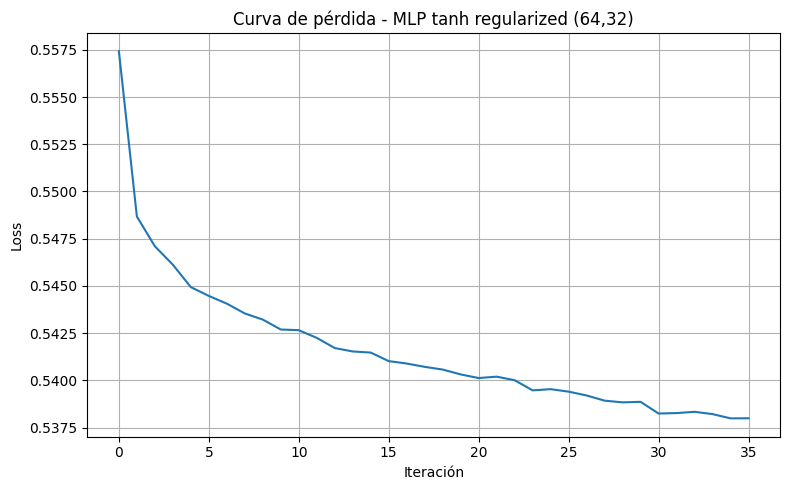

In [19]:
selected_mlp = candidate_model.named_steps["model"]

print("Iteraciones realizadas:", selected_mlp.n_iter_)
print("Loss final:", selected_mlp.loss_)

if hasattr(selected_mlp, "loss_curve_"):
    plt.figure(figsize=(8, 5))
    plt.plot(selected_mlp.loss_curve_)
    plt.xlabel("Iteración")
    plt.ylabel("Loss")
    plt.title(f"Curva de pérdida - {candidate_model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 14. Curvas ROC en validación

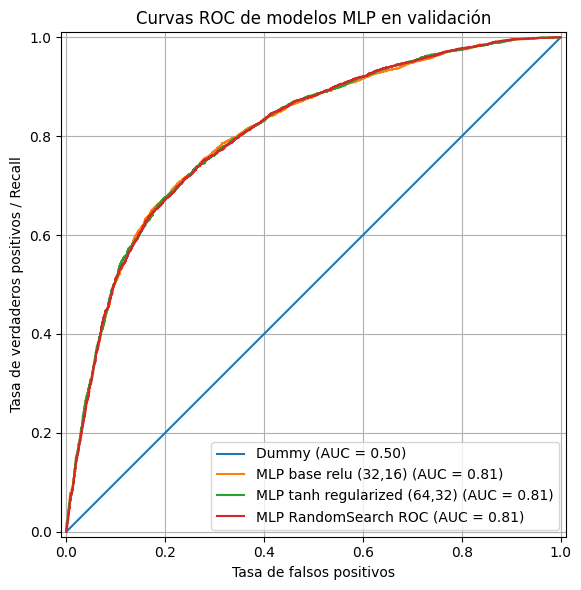

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, model in all_mlp_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_val,
        y_val,
        ax=ax,
        name=model_name
    )

plt.title("Curvas ROC de modelos MLP en validación")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos / Recall")
plt.grid(True)
plt.tight_layout()
plt.show()

## 15. Ajuste de threshold en validación

El modelo se selecciona por ROC-AUC.  
Después, el threshold operativo se ajusta en validación usando F2, porque F2 prioriza recall y es relevante en el contexto cardiovascular.

Importante: el threshold se ajusta **solo en validation**, nunca en test.

In [21]:
val_scores = get_decision_scores(candidate_model, X_val)

threshold_grid = np.linspace(0.05, 0.95, 181)

threshold_results = []

for threshold in threshold_grid:
    y_val_pred_threshold = (val_scores >= threshold).astype(int)

    scores, cm = get_scores_from_predictions(
        y_true=y_val,
        y_pred=y_val_pred_threshold,
        y_score=val_scores,
        model_name=candidate_model_name,
        split_name=f"validation_threshold_{threshold:.3f}"
    )

    scores["threshold"] = threshold
    threshold_results.append(scores)

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_sorted = threshold_results_df.sort_values(
    by=["f2", "FN", "recall"],
    ascending=[False, True, False]
)

threshold_results_sorted.head(10)

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP,threshold
32,"MLP tanh regularized (64,32)",validation_threshold_0.210,0.610001,0.561782,0.965253,0.710216,0.844019,0.806683,906,2557,118,3278,0.210
33,"MLP tanh regularized (64,32)",validation_threshold_0.215,0.614229,0.564812,0.962309,0.711827,0.843573,0.806683,945,2518,128,3268,0.215
30,"MLP tanh regularized (64,32)",validation_threshold_0.200,0.599067,0.554395,0.969376,0.705378,0.843151,0.806683,817,2646,104,3292,0.200
31,"MLP tanh regularized (64,32)",validation_threshold_0.205,0.603878,0.557669,0.966726,0.707314,0.843049,0.806683,859,2604,113,3283,0.205
29,"MLP tanh regularized (64,32)",validation_threshold_0.195,0.595276,0.551874,0.971143,0.703799,0.843047,0.806683,785,2678,98,3298,0.195
28,"MLP tanh regularized (64,32)",validation_threshold_0.190,0.590465,0.548746,0.972909,0.701710,0.842642,0.806683,746,2717,92,3304,0.190
25,"MLP tanh regularized (64,32)",validation_threshold_0.175,0.575303,0.539097,0.980565,0.695707,0.842569,0.806683,616,2847,66,3330,0.175
24,"MLP tanh regularized (64,32)",validation_threshold_0.170,0.571075,0.536507,0.982332,0.693988,0.842339,0.806683,581,2882,60,3336,0.170
26,"MLP tanh regularized (64,32)",validation_threshold_0.180,0.580114,0.542129,0.977621,0.697479,0.842298,0.806683,659,2804,76,3320,0.180
21,"MLP tanh regularized (64,32)",validation_threshold_0.155,0.559411,0.529523,0.987633,0.689414,0.841952,0.806683,483,2980,42,3354,0.155


In [22]:
best_threshold = float(threshold_results_sorted.iloc[0]["threshold"])

print("Mejor threshold según F2 en validation:", best_threshold)

best_threshold_val_scores = threshold_results_sorted.iloc[0]
best_threshold_val_scores

Mejor threshold según F2 en validation: 0.20999999999999996


model        MLP tanh regularized (64,32)
split          validation_threshold_0.210
accuracy                         0.610001
precision                        0.561782
recall                           0.965253
f1                               0.710216
f2                               0.844019
roc_auc                          0.806683
TN                                    906
FP                                   2557
FN                                    118
TP                                   3278
threshold                            0.21
Name: 32, dtype: object

## 15.1 Curva de métricas por threshold

Esta gráfica ayuda a verificar que el threshold ajustado por F2 no se eligió de forma opaca.


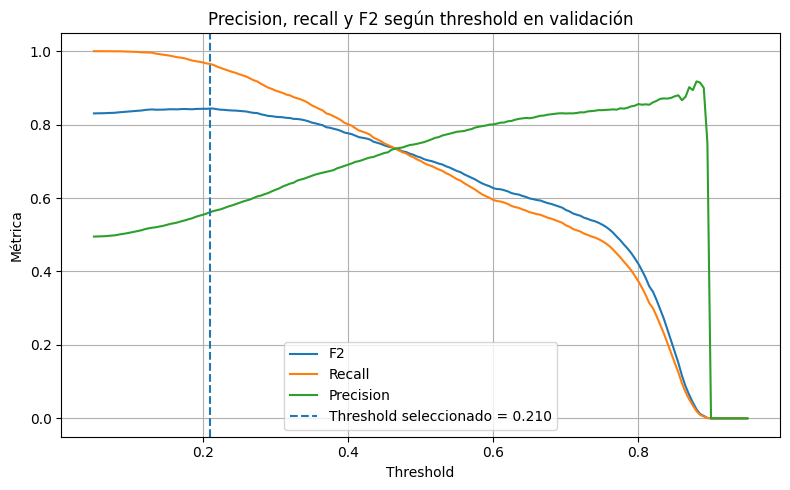

In [23]:
selected_threshold_for_plot = float(threshold_results_sorted.iloc[0]["threshold"])

plt.figure(figsize=(8, 5))

plt.plot(threshold_results_df["threshold"], threshold_results_df["f2"], label="F2")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], label="Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], label="Precision")

plt.axvline(
    selected_threshold_for_plot,
    linestyle="--",
    label=f"Threshold seleccionado = {selected_threshold_for_plot:.3f}"
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Precision, recall y F2 según threshold en validación")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 16. Matriz de confusión en validación con threshold ajustado

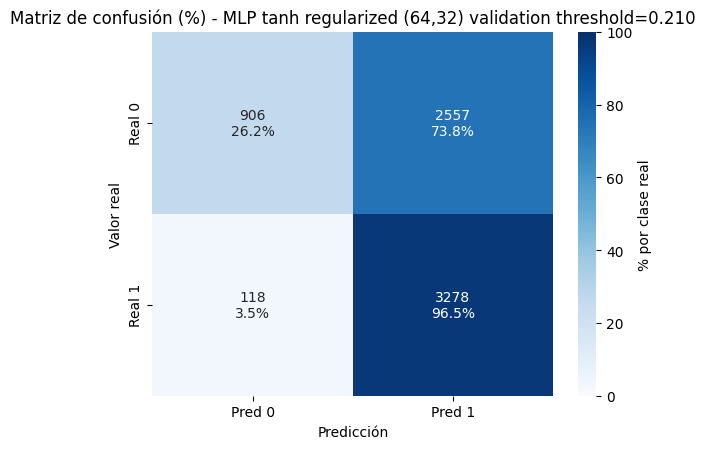

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
0,"MLP tanh regularized (64,32)",validation_adjusted_threshold,0.610001,0.561782,0.965253,0.710216,0.844019,0.806683,906,2557,118,3278


In [24]:
y_val_pred_adjusted = (val_scores >= best_threshold).astype(int)

val_adjusted_scores, val_adjusted_cm = get_scores_from_predictions(
    y_true=y_val,
    y_pred=y_val_pred_adjusted,
    y_score=val_scores,
    model_name=candidate_model_name,
    split_name="validation_adjusted_threshold"
)

plot_confusion_matrix_percent(
    val_adjusted_cm,
    title=f"Matriz de confusión (%) - {candidate_model_name} validation threshold={best_threshold:.3f}",
    class_labels=("0", "1")
)

pd.DataFrame([val_adjusted_scores])


## 17. Evaluación final en test

Se evalúa en test usando:

1. threshold por defecto 0.5;
2. threshold ajustado en validation.

El test no se usa para escoger modelo ni threshold.

In [25]:
test_scores_raw = get_decision_scores(candidate_model, X_test)

test_pred_default = (test_scores_raw >= 0.5).astype(int)
test_default_scores, test_default_cm = get_scores_from_predictions(
    y_true=y_test,
    y_pred=test_pred_default,
    y_score=test_scores_raw,
    model_name=candidate_model_name,
    split_name="test_default_threshold"
)

test_pred_adjusted = (test_scores_raw >= best_threshold).astype(int)
test_adjusted_scores, test_adjusted_cm = get_scores_from_predictions(
    y_true=y_test,
    y_pred=test_pred_adjusted,
    y_score=test_scores_raw,
    model_name=candidate_model_name,
    split_name="test_adjusted_threshold"
)

test_results = pd.DataFrame([
    test_default_scores,
    test_adjusted_scores
])

test_results

,model,split,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
0,"MLP tanh regularized (64,32)",test_default_threshold,0.741216,0.760954,0.695729,0.726881,0.707864,0.804413,2722,742,1033,2362
1,"MLP tanh regularized (64,32)",test_adjusted_threshold,0.599650,0.555385,0.958468,0.703263,0.836977,0.804413,859,2605,141,3254


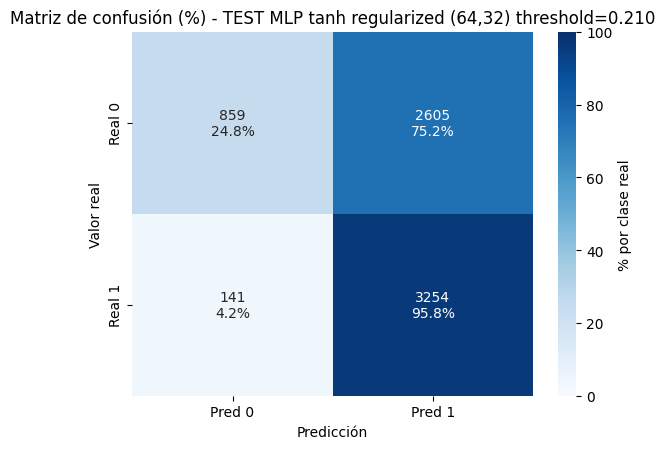

In [26]:
plot_confusion_matrix_percent(
    test_adjusted_cm,
    title=f"Matriz de confusión (%) - TEST {candidate_model_name} threshold={best_threshold:.3f}",
    class_labels=("0", "1")
)


In [27]:
print(classification_report(
    y_test,
    test_pred_adjusted,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.86      0.25      0.38      3464
           1       0.56      0.96      0.70      3395

    accuracy                           0.60      6859
   macro avg       0.71      0.60      0.54      6859
weighted avg       0.71      0.60      0.54      6859



## 18. Exportar modelo MLP seleccionado

Se exporta un `model_bundle` con:

- modelo entrenado completo,
- nombre del modelo,
- threshold ajustado,
- columnas esperadas,
- métrica oficial,
- resultados de validación,
- resultados de test.

El archivo se descarga manualmente y luego se ubica en la carpeta del repositorio:

```text
ExportedModels/mlp_roc_selected_model.joblib
```

In [31]:
import joblib

MODEL_FILENAME = "exported_mlp.joblib"
MODEL_PATH = Path(MODEL_FILENAME)

model_bundle = {
    "model": candidate_model,
    "model_name": candidate_model_name,
    "threshold": float(best_threshold),
    "target_column": target_column,
    "feature_columns": list(X_train.columns),
    "official_metric": official_refit_metric,
    "validation_results": all_validation_results,
    "threshold_validation_results": threshold_results_sorted,
    "test_results": test_results
}

joblib.dump(model_bundle, MODEL_PATH)

print(f"Modelo exportado correctamente en: {MODEL_PATH.resolve()}")


Modelo exportado correctamente en: /kaggle/working/exported_mlp.joblib


## 19. Ejemplo de carga del modelo exportado

In [32]:
loaded_bundle = joblib.load("exported_mlp.joblib")

loaded_model = loaded_bundle["model"]
loaded_threshold = loaded_bundle["threshold"]

loaded_scores = get_decision_scores(loaded_model, X_test)
loaded_predictions = (loaded_scores >= loaded_threshold).astype(int)

loaded_predictions[:10]


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [33]:
original_predictions = (get_decision_scores(candidate_model, X_test) >= best_threshold).astype(int)

print("Predicciones iguales:", (original_predictions == loaded_predictions).all())

Predicciones iguales: True
